# Демонстрация Feature Engine: 50+ фич для AAPL

Этот ноутбук демонстрирует работу системы расчёта фичей:
- Загрузка исторических данных AAPL (5 лет)
- Расчёт 50+ технических индикаторов и price-based фич
- Визуализация ключевых фич
- Сводная таблица всех фич

## ⚠️ Важно перед запуском!

**Если видите ошибку `FileNotFoundError: config/config.yaml`:**
1. Убедитесь, что запускаете ноутбук из корня проекта или через Jupyter Lab
2. Перезапустите kernel: `Kernel → Restart Kernel`
3. Запустите все ячейки последовательно (`Cell → Run All`)

**Текущая конфигурация:**
- Ноутбук автоматически определяет корень проекта через `os.getcwd()`
- Все пути настроены как абсолютные относительно project_root
- Кеш фич: `data/processed/features/`
- Результаты: `data/processed/`

In [12]:
import sys
import os

# Добавляем корень проекта в sys.path для импорта src.*
# Используем относительный путь от текущей директории ноутбука
notebook_dir = os.getcwd()
project_root = os.path.abspath(os.path.join(notebook_dir, '../..'))

if project_root not in sys.path:
    sys.path.insert(0, project_root)

print(f"✓ Добавлен путь: {project_root}")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta

# Наши модули
from src.data.data_manager import DataManager
from src.features.feature_engine import FeatureEngine
from src.features.feature_registry import register_all_features, get_feature_count

# Настройки визуализации
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

print("✓ Все модули загружены")

✓ Добавлен путь: /Users/semenzidkov/market-pricing-prj
✓ Все модули загружены


In [13]:
# Проверяем, что все пути корректны
print(f"📁 Project root: {project_root}")
print(f"📁 Config exists: {os.path.exists(os.path.join(project_root, 'config', 'config.yaml'))}")
print(f"📁 Data dir exists: {os.path.exists(os.path.join(project_root, 'data'))}")
print(f"📁 Current working directory: {os.getcwd()}")

📁 Project root: /Users/semenzidkov/market-pricing-prj
📁 Config exists: True
📁 Data dir exists: True
📁 Current working directory: /Users/semenzidkov/market-pricing-prj/notebooks/exploratory


## 1. Загрузка данных AAPL за 5 лет

In [14]:
# Загружаем данные через DataManager
# Указываем полный путь к конфигу относительно корня проекта
config_path = os.path.join(project_root, 'config', 'config.yaml')
data_manager = DataManager(config_path=config_path)

# AAPL за 5 лет
print("Загрузка данных AAPL...")
df = data_manager.get_stock_data('AAPL', timeframe='1d', period='5y', use_cache=True)

print(f"\nЗагружено {len(df)} дней данных")
print(f"Период: {df.index.min().date()} - {df.index.max().date()}")
print(f"\nПервые строки:")
df.head()

INFO:src.data.data_manager:Загрузка из кэша: AAPL
INFO:src.data.data_manager:Загрузка из кэша: AAPL


Загрузка данных AAPL...

Загружено 250 дней данных
Период: 2024-11-05 - 2025-11-04

Первые строки:

Загружено 250 дней данных
Период: 2024-11-05 - 2025-11-04

Первые строки:


,open,high,low,close,volume,dividend,symbol,asset_type,data_loaded_at
date,,,,,,,,,
2024-11-05,221.800003,223.949997,221.139999,223.449997,28111300,0.00,AAPL,stocks,2025-11-05 11:22:44.362295
2024-11-06,222.610001,226.070007,221.190002,222.720001,54561100,0.00,AAPL,stocks,2025-11-05 11:22:44.362295
2024-11-07,224.630005,227.880005,224.570007,227.479996,42137700,0.00,AAPL,stocks,2025-11-05 11:22:44.362295
2024-11-08,227.169998,228.660004,226.410004,226.960007,38328800,0.25,AAPL,stocks,2025-11-05 11:22:44.362295
2024-11-11,225.000000,225.699997,221.500000,224.229996,42005600,0.00,AAPL,stocks,2025-11-05 11:22:44.362295


## 2. Инициализация Feature Engine и регистрация всех фич

In [15]:
# Создаём engine с абсолютным путём к кешу
cache_dir = os.path.join(project_root, 'data', 'processed', 'features')
engine = FeatureEngine(cache_dir=cache_dir, version='1.0.0')

# Регистрируем все 50+ фич
register_all_features(engine)

# Получаем статистику
summary = engine.get_summary()

print(f"Feature Engine v{summary['engine_version']}")
print(f"\n📊 Всего зарегистрировано фич: {summary['total_features']}")
print(f"\n📦 Фич по группам:")
for group, count in summary['groups'].items():
    print(f"  - {group}: {count} фич")

INFO:src.features.feature_engine:FeatureEngine v1.0.0 инициализирован


Feature Engine v1.0.0

📊 Всего зарегистрировано фич: 56

📦 Фич по группам:
  - technical: 22 фич
  - price_based: 24 фич
  - rolling: 10 фич


## 3. Расчёт всех фич

Это может занять 30-60 секунд в первый раз. Последующие запуски будут использовать кеш.

In [16]:
import time

start_time = time.time()

print("Расчёт всех фич...")
df_with_features = engine.compute_all(df, use_cache=True)

elapsed = time.time() - start_time

print(f"\n✓ Расчёт завершён за {elapsed:.1f} секунд")
print(f"Исходных колонок: {len(df.columns)}")
print(f"Итоговых колонок: {len(df_with_features.columns)}")
print(f"Добавлено фич: {len(df_with_features.columns) - len(df.columns)}")

# Показываем список всех колонок
print(f"\n📋 Список всех фич:")
feature_cols = [col for col in df_with_features.columns if col not in df.columns]
for i, col in enumerate(sorted(feature_cols), 1):
    print(f"  {i:2d}. {col}")

INFO:src.features.feature_engine:Расчёт 56 фичей...
INFO:src.features.feature_engine:Фича 'rsi_14' вычислена за 0.006s
INFO:src.features.feature_engine:Фича 'rsi_14' вычислена за 0.006s
INFO:src.features.feature_engine:Фича 'macd' вычислена за 0.001s
INFO:src.features.feature_engine:Фича 'stochastic' вычислена за 0.001s
INFO:src.features.feature_engine:Фича 'macd' вычислена за 0.001s
INFO:src.features.feature_engine:Фича 'stochastic' вычислена за 0.001s
INFO:src.features.feature_engine:Фича 'cci_20' вычислена за 0.003s
INFO:src.features.feature_engine:Фича 'cci_20' вычислена за 0.003s
INFO:src.features.feature_engine:Фича 'williams_r_14' вычислена за 0.005s
INFO:src.features.feature_engine:Фича 'mfi_14' вычислена за 0.001s
INFO:src.features.feature_engine:Фича 'roc_12' вычислена за 0.000s
INFO:src.features.feature_engine:Фича 'williams_r_14' вычислена за 0.005s
INFO:src.features.feature_engine:Фича 'mfi_14' вычислена за 0.001s
INFO:src.features.feature_engine:Фича 'roc_12' вычислена за

Расчёт всех фич...


INFO:src.features.feature_engine:Фича 'garman_klass_vol_20' вычислена за 0.019s
INFO:src.features.feature_engine:Фича 'atr_percent' вычислена за 0.023s
INFO:src.features.feature_engine:Фича 'atr_percent' вычислена за 0.023s
INFO:src.features.feature_engine:Фича 'volatility_regime' вычислена за 0.007s
INFO:src.features.feature_engine:Фича 'price_momentum' вычислена за 0.001s
INFO:src.features.feature_engine:Фича 'volatility_regime' вычислена за 0.007s
INFO:src.features.feature_engine:Фича 'price_momentum' вычислена за 0.001s
INFO:src.features.feature_engine:Фича 'price_acceleration' вычислена за 0.001s
INFO:src.features.feature_engine:Фича 'rolling_zscore_20' вычислена за 0.001s
INFO:src.features.feature_engine:Фича 'price_acceleration' вычислена за 0.001s
INFO:src.features.feature_engine:Фича 'rolling_zscore_20' вычислена за 0.001s
INFO:src.features.feature_engine:Фича 'distance_from_high_252' вычислена за 0.001s
INFO:src.features.feature_engine:Фича 'distance_from_low_252' вычислена з


✓ Расчёт завершён за 0.9 секунд
Исходных колонок: 9
Итоговых колонок: 100
Добавлено фич: 91

📋 Список всех фич:
   1. ad_line
   2. adx
   3. aroon_down
   4. aroon_osc
   5. aroon_up
   6. atr_14
   7. atr_percent
   8. autocorr_lag_1
   9. autocorr_lag_10
  10. autocorr_lag_20
  11. autocorr_lag_5
  12. bb_lower
  13. bb_middle
  14. bb_pct
  15. bb_upper
  16. bb_width
  17. body_size
  18. cci_20
  19. cmf_20
  20. daily_range
  21. dc_lower
  22. dc_middle
  23. dc_upper
  24. death_cross
  25. di_minus
  26. di_plus
  27. distance_from_high_252
  28. distance_from_low_252
  29. ema_12
  30. ema_20
  31. ema_26
  32. ema_cross_12_26
  33. ema_diff_12_26
  34. forward_returns_1d
  35. gap
  36. garman_klass_vol_20
  37. golden_cross
  38. hurst_exponent
  39. ichimoku_kijun
  40. ichimoku_senkou_a
  41. ichimoku_senkou_b
  42. ichimoku_tenkan
  43. kc_lower
  44. kc_middle
  45. kc_upper
  46. linear_regression_slope
  47. log_returns
  48. lower_shadow
  49. macd
  50. macd_hist


## 4. Сводная таблица: последние значения ключевых фич

In [17]:
# Выбираем ключевые фичи для демонстрации
key_features = [
    'close', 'rsi_14', 'macd', 'macd_signal', 
    'atr_14', 'bb_upper', 'bb_middle', 'bb_lower',
    'adx', 'obv', 'returns_1d', 'realized_vol_20',
    'rolling_zscore_20', 'distance_from_high_252',
    'trend_strength', 'volatility_regime'
]

# Последние 10 дней
latest = df_with_features[key_features].tail(10)

print("📈 Последние значения ключевых фич (последние 10 дней):\n")
display(latest.round(3))

📈 Последние значения ключевых фич (последние 10 дней):



,close,rsi_14,macd,macd_signal,atr_14,bb_upper,bb_middle,bb_lower,adx,obv,returns_1d,realized_vol_20,rolling_zscore_20,distance_from_high_252,trend_strength,volatility_regime
date,,,,,,,,,,,,,,,,
2025-10-22,258.45,51.557,3.982,4.018,5.514,264.266,254.525,244.784,37.331,1.022672e+09,-0.016,0.239,0.806,NaN,0.004,1
2025-10-23,259.58,51.829,4.070,4.029,5.323,264.612,254.660,244.709,32.301,1.055427e+09,0.004,0.231,0.989,NaN,0.004,1
2025-10-24,262.82,56.880,4.350,4.093,5.389,265.628,255.028,244.429,27.578,1.093681e+09,0.012,0.234,1.470,NaN,0.042,1
2025-10-27,268.81,62.249,4.999,4.274,5.699,267.998,255.747,243.497,23.526,1.138569e+09,0.023,0.244,2.133,NaN,0.129,1
2025-10-28,269.00,61.177,5.465,4.512,5.651,270.054,256.466,242.878,19.430,1.180104e+09,0.001,0.244,1.845,NaN,0.224,1
2025-10-29,269.70,67.164,5.824,4.775,5.606,271.982,257.178,242.375,17.828,1.231191e+09,0.003,0.244,1.692,NaN,0.328,1
2025-10-30,271.40,83.891,6.174,5.054,5.126,274.003,257.892,241.781,19.517,1.301077e+09,0.006,0.244,1.677,NaN,0.456,1
2025-10-31,270.37,80.532,6.296,5.303,5.394,275.561,258.509,241.458,21.159,1.214910e+09,-0.004,0.245,1.391,NaN,0.582,1
2025-11-03,269.05,77.708,6.214,5.485,5.426,276.786,259.127,241.469,22.665,1.164716e+09,-0.005,0.245,1.124,NaN,0.670,1


## 5. Визуализация: Цена и технические индикаторы

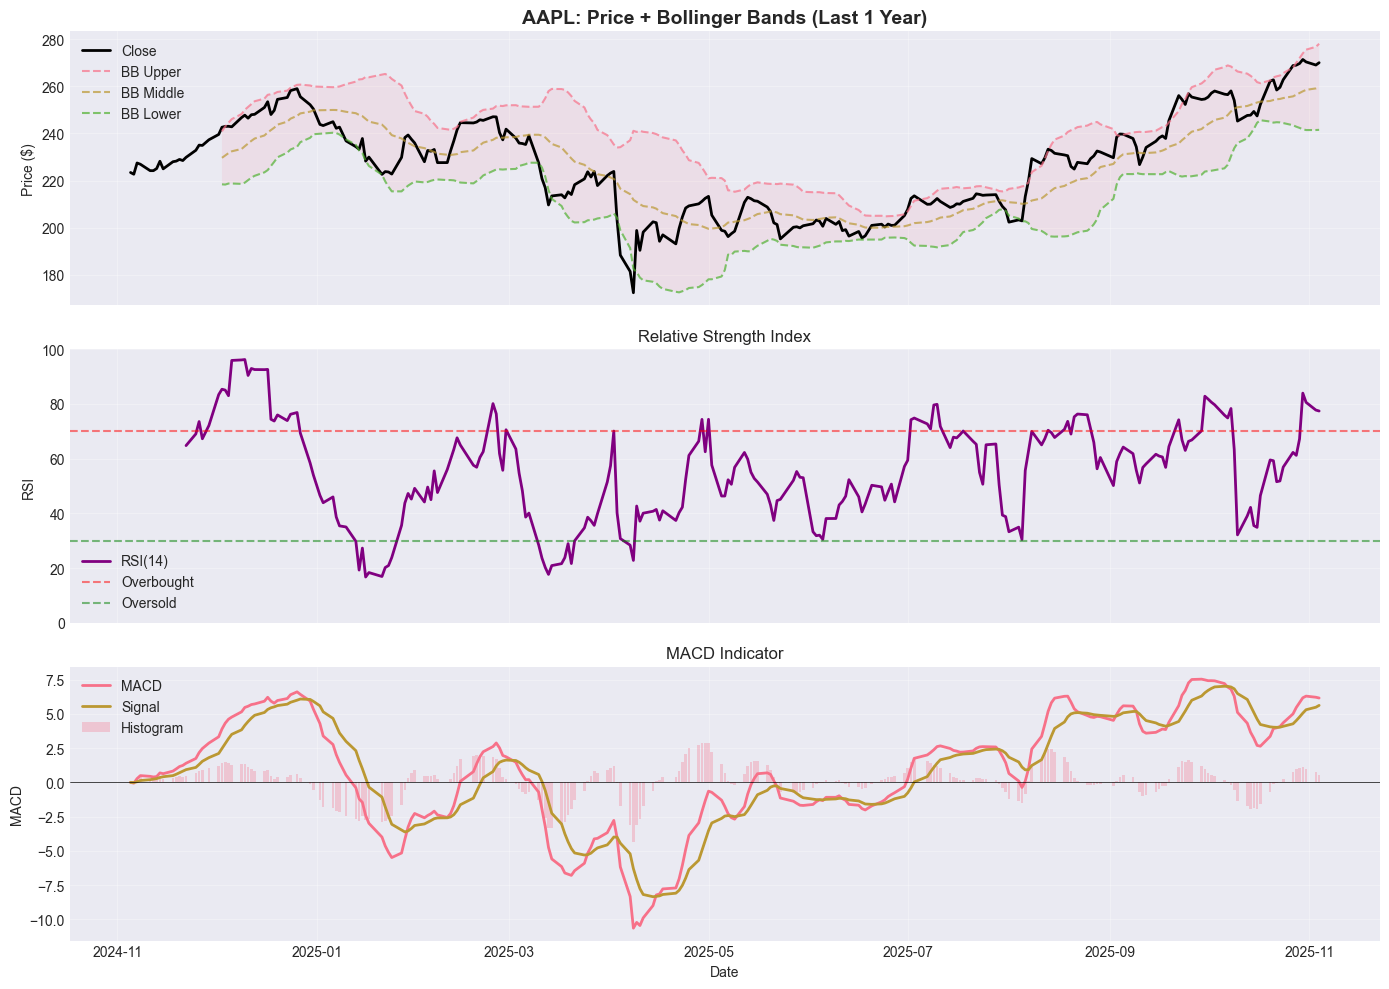

In [18]:
# График 1: Цена + Bollinger Bands + SMA
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

# Последние 252 дня (1 год)
plot_data = df_with_features.tail(252)

# Subplot 1: Price + BB + SMA
ax1 = axes[0]
ax1.plot(plot_data.index, plot_data['close'], label='Close', linewidth=2, color='black')
ax1.plot(plot_data.index, plot_data['bb_upper'], label='BB Upper', linestyle='--', alpha=0.7)
ax1.plot(plot_data.index, plot_data['bb_middle'], label='BB Middle', linestyle='--', alpha=0.7)
ax1.plot(plot_data.index, plot_data['bb_lower'], label='BB Lower', linestyle='--', alpha=0.7)
ax1.fill_between(plot_data.index, plot_data['bb_upper'], plot_data['bb_lower'], alpha=0.1)
ax1.set_ylabel('Price ($)')
ax1.set_title('AAPL: Price + Bollinger Bands (Last 1 Year)', fontsize=14, fontweight='bold')
ax1.legend(loc='best')
ax1.grid(True, alpha=0.3)

# Subplot 2: RSI
ax2 = axes[1]
ax2.plot(plot_data.index, plot_data['rsi_14'], label='RSI(14)', linewidth=2, color='purple')
ax2.axhline(70, color='red', linestyle='--', alpha=0.5, label='Overbought')
ax2.axhline(30, color='green', linestyle='--', alpha=0.5, label='Oversold')
ax2.set_ylabel('RSI')
ax2.set_title('Relative Strength Index', fontsize=12)
ax2.legend(loc='best')
ax2.grid(True, alpha=0.3)
ax2.set_ylim(0, 100)

# Subplot 3: MACD
ax3 = axes[2]
ax3.plot(plot_data.index, plot_data['macd'], label='MACD', linewidth=2)
ax3.plot(plot_data.index, plot_data['macd_signal'], label='Signal', linewidth=2)
ax3.bar(plot_data.index, plot_data['macd_hist'], label='Histogram', alpha=0.3)
ax3.axhline(0, color='black', linestyle='-', linewidth=0.5)
ax3.set_ylabel('MACD')
ax3.set_xlabel('Date')
ax3.set_title('MACD Indicator', fontsize=12)
ax3.legend(loc='best')
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 6. Визуализация: Волатильность и тренды

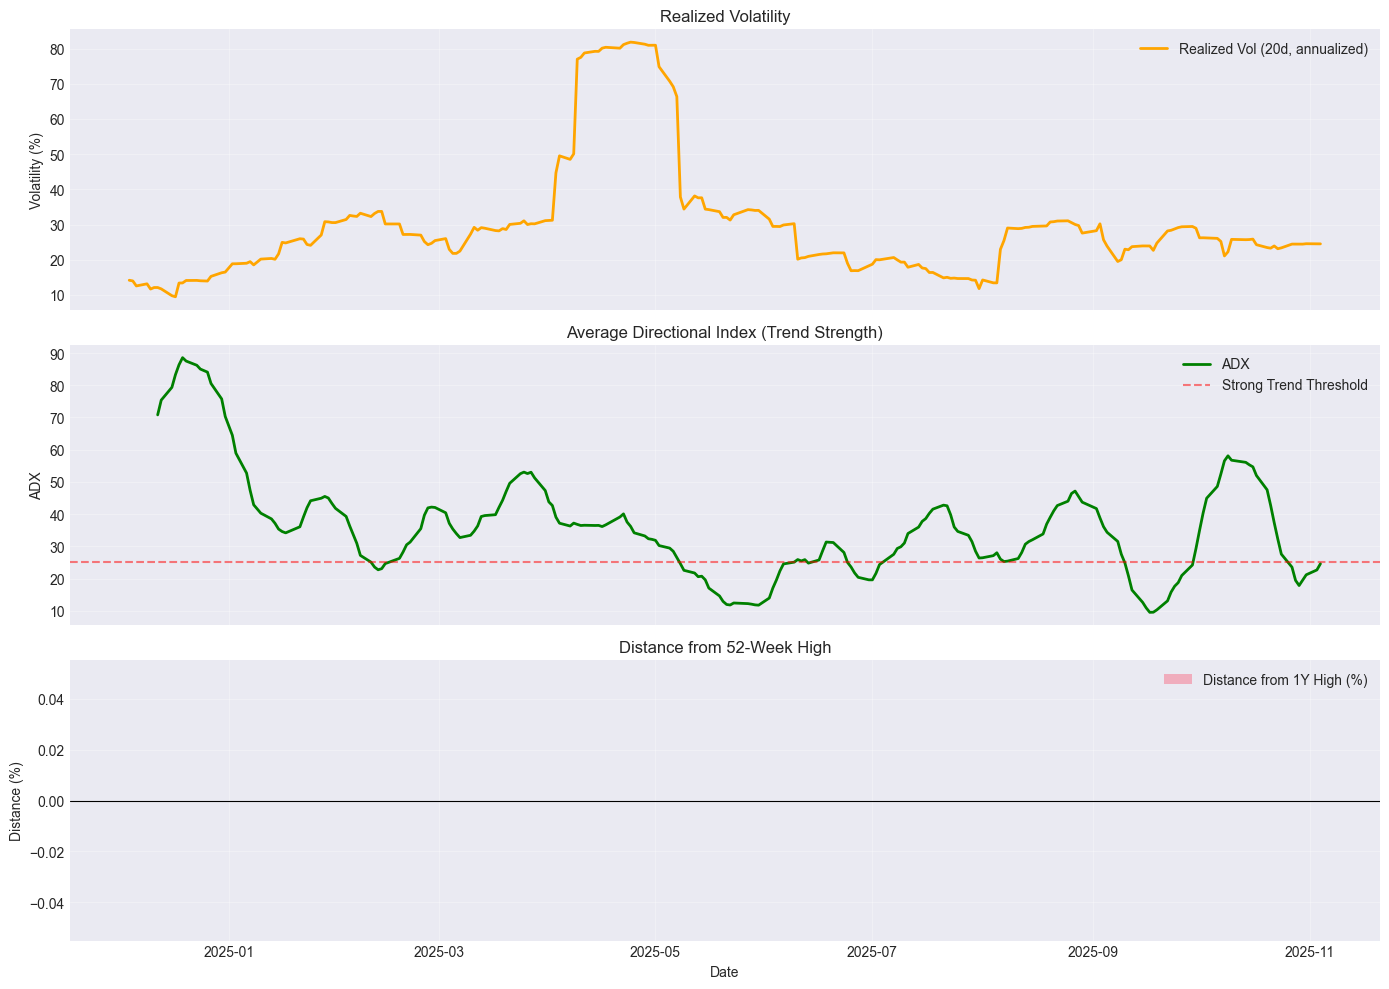

In [19]:
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

# Subplot 1: Realized Volatility
ax1 = axes[0]
ax1.plot(plot_data.index, plot_data['realized_vol_20'] * 100, 
         label='Realized Vol (20d, annualized)', linewidth=2, color='orange')
ax1.set_ylabel('Volatility (%)')
ax1.set_title('Realized Volatility', fontsize=12)
ax1.legend(loc='best')
ax1.grid(True, alpha=0.3)

# Subplot 2: ADX (Trend Strength)
ax2 = axes[1]
ax2.plot(plot_data.index, plot_data['adx'], label='ADX', linewidth=2, color='green')
ax2.axhline(25, color='red', linestyle='--', alpha=0.5, label='Strong Trend Threshold')
ax2.set_ylabel('ADX')
ax2.set_title('Average Directional Index (Trend Strength)', fontsize=12)
ax2.legend(loc='best')
ax2.grid(True, alpha=0.3)

# Subplot 3: Distance from High
ax3 = axes[2]
ax3.fill_between(plot_data.index, 0, plot_data['distance_from_high_252'], 
                 alpha=0.5, label='Distance from 1Y High (%)')
ax3.axhline(0, color='black', linestyle='-', linewidth=0.8)
ax3.set_ylabel('Distance (%)')
ax3.set_xlabel('Date')
ax3.set_title('Distance from 52-Week High', fontsize=12)
ax3.legend(loc='best')
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 7. Корреляционная матрица ключевых фич

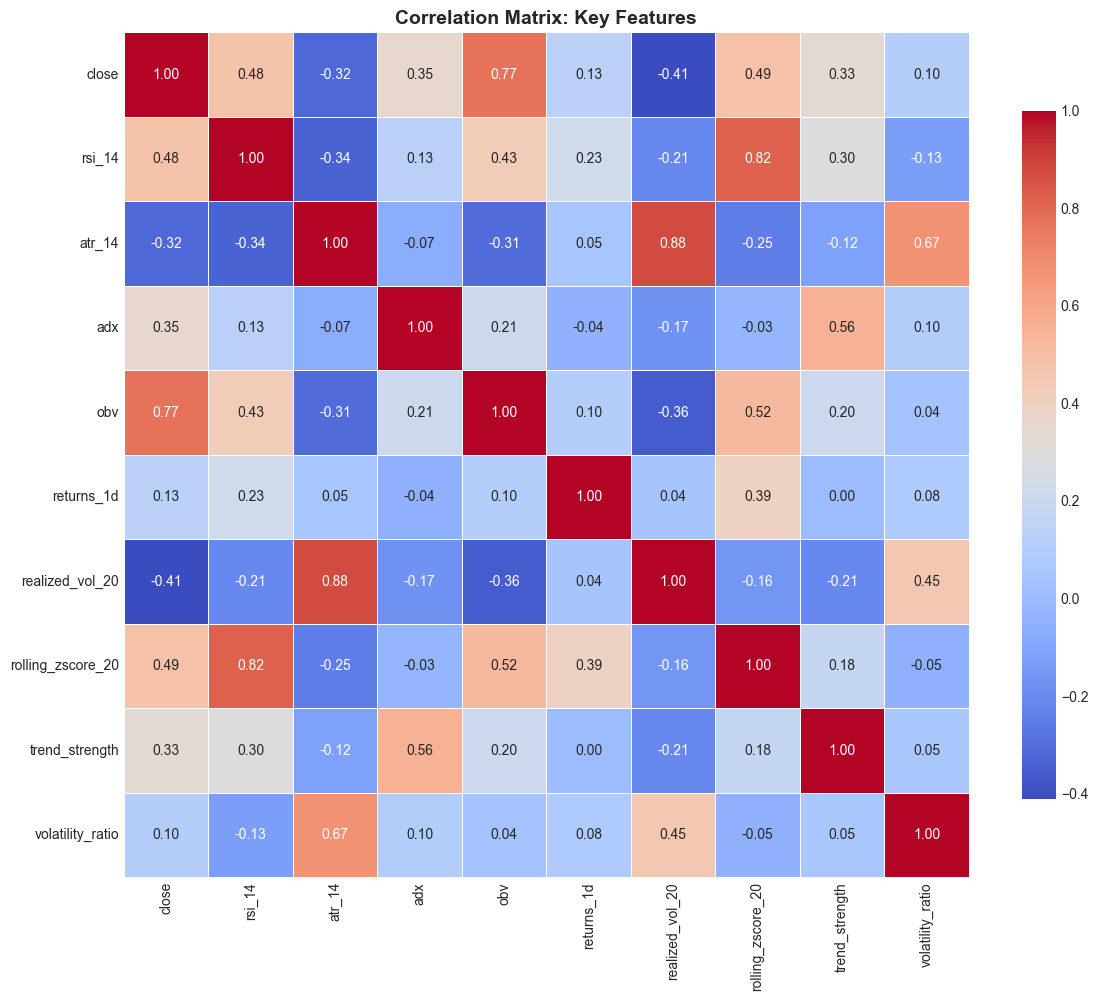

In [20]:
# Выбираем числовые фичи для корреляции
numeric_features = [
    'close', 'rsi_14', 'atr_14', 'adx', 'obv',
    'returns_1d', 'realized_vol_20', 'rolling_zscore_20',
    'trend_strength', 'volatility_ratio'
]

# Корреляционная матрица
corr_matrix = df_with_features[numeric_features].corr()

# Визуализация
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('Correlation Matrix: Key Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 8. Распределение фич: Histograms

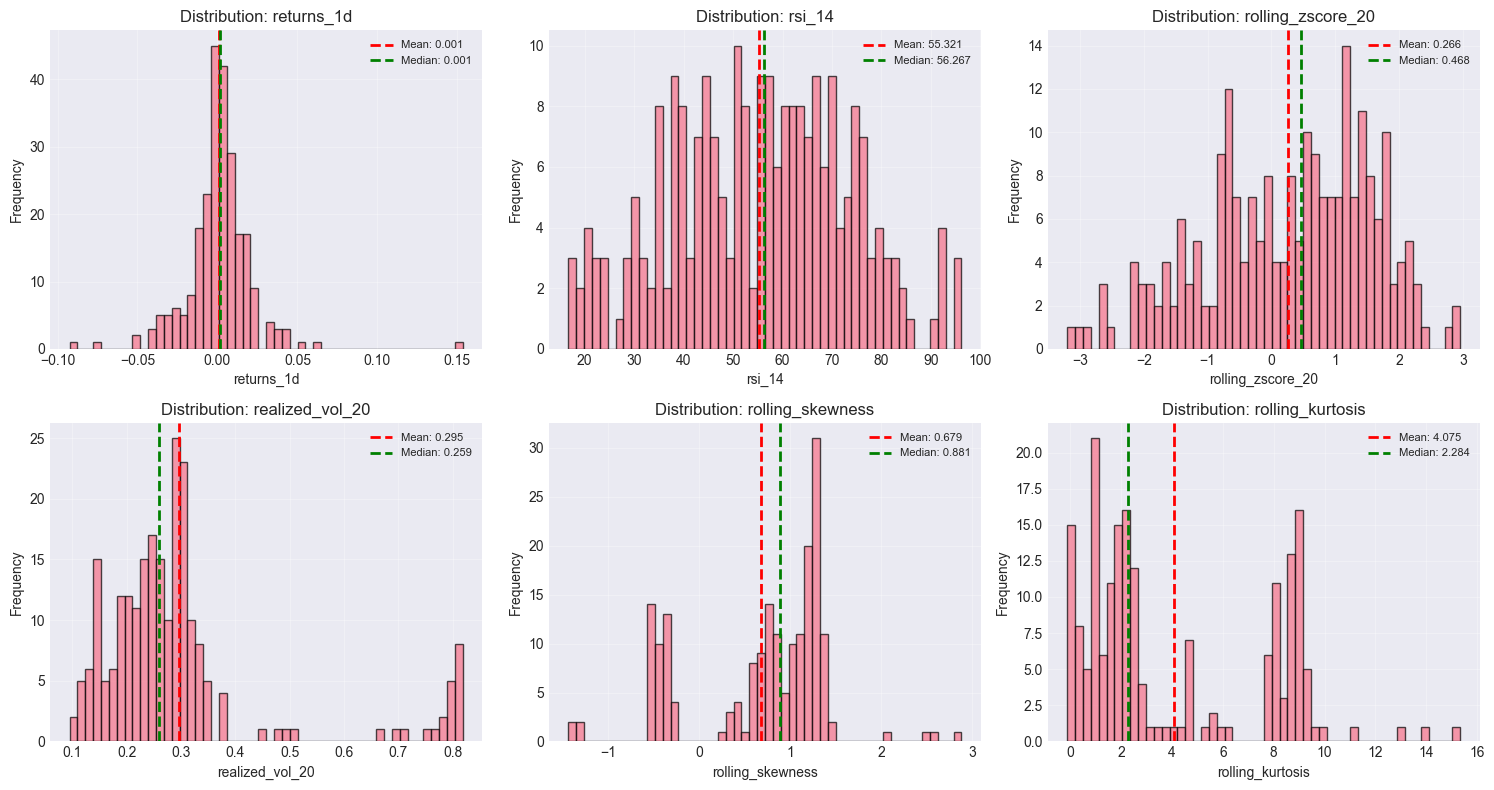

In [21]:
# Выбираем 6 интересных фич для гистограмм
features_to_plot = [
    'returns_1d', 'rsi_14', 'rolling_zscore_20',
    'realized_vol_20', 'rolling_skewness', 'rolling_kurtosis'
]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, feature in enumerate(features_to_plot):
    ax = axes[i]
    data = df_with_features[feature].dropna()
    
    ax.hist(data, bins=50, alpha=0.7, edgecolor='black')
    ax.axvline(data.mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {data.mean():.3f}')
    ax.axvline(data.median(), color='green', linestyle='--', linewidth=2, label=f'Median: {data.median():.3f}')
    ax.set_xlabel(feature)
    ax.set_ylabel('Frequency')
    ax.set_title(f'Distribution: {feature}')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 9. Feature Importance: Корреляция с будущей доходностью

Проверим, какие фичи лучше всего предсказывают будущую доходность (forward_returns_1d).

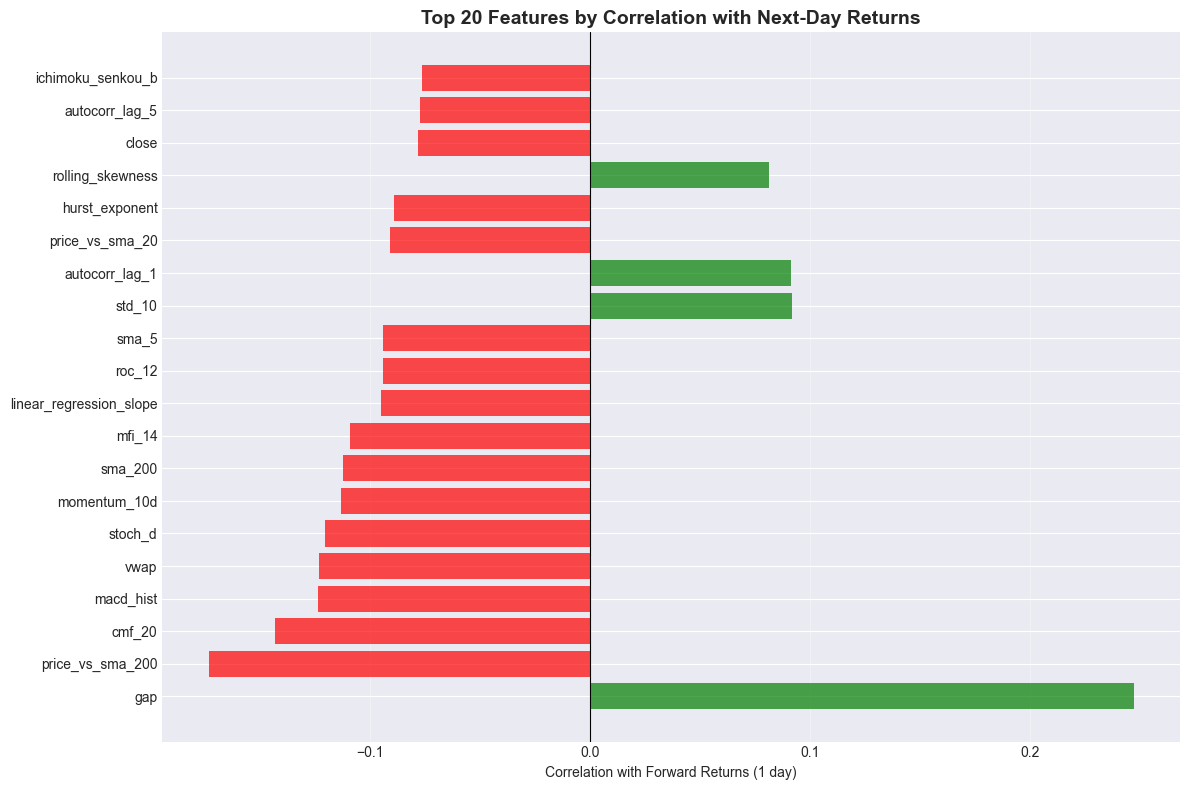


📊 Top 10 features correlated with forward returns:
   1. gap                           : +0.2470
   2. price_vs_sma_200              : -0.1731
   3. cmf_20                        : -0.1431
   4. macd_hist                     : -0.1234
   5. vwap                          : -0.1230
   6. stoch_d                       : -0.1201
   7. momentum_10d                  : -0.1130
   8. sma_200                       : -0.1121
   9. mfi_14                        : -0.1091
  10. linear_regression_slope       : -0.0950


In [22]:
# Вычисляем корреляцию всех фич с forward returns
target = 'forward_returns_1d'

# Берём только числовые колонки
numeric_cols = df_with_features.select_dtypes(include=[np.number]).columns
numeric_cols = [col for col in numeric_cols if col not in ['symbol', target]]

correlations = {}
for col in numeric_cols:
    corr = df_with_features[[col, target]].corr().iloc[0, 1]
    correlations[col] = corr

# Сортируем по абсолютному значению
corr_series = pd.Series(correlations).sort_values(key=abs, ascending=False)

# Топ-20 фич
top_features = corr_series.head(20)

# Визуализация
plt.figure(figsize=(12, 8))
colors = ['green' if x > 0 else 'red' for x in top_features.values]
plt.barh(range(len(top_features)), top_features.values, color=colors, alpha=0.7)
plt.yticks(range(len(top_features)), top_features.index, fontsize=10)
plt.xlabel('Correlation with Forward Returns (1 day)')
plt.title('Top 20 Features by Correlation with Next-Day Returns', fontsize=14, fontweight='bold')
plt.axvline(0, color='black', linewidth=0.8)
plt.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

print("\n📊 Top 10 features correlated with forward returns:")
for i, (feat, corr) in enumerate(top_features.head(10).items(), 1):
    print(f"  {i:2d}. {feat:30s}: {corr:+.4f}")

## 10. Сводка: Статистика по всем фичам

In [23]:
# Создаём сводную таблицу статистики
feature_cols_only = [col for col in df_with_features.columns if col not in df.columns]

stats = df_with_features[feature_cols_only].describe().T
stats['missing_%'] = (df_with_features[feature_cols_only].isnull().sum() / len(df_with_features) * 100)

print(f"\n📋 Статистика по всем {len(feature_cols_only)} фичам:\n")
display(stats.round(3))


📋 Статистика по всем 91 фичам:



,count,mean,std,min,25%,50%,75%,max,missing_%
rsi_14,237.0,55.321,18.012,16.748,42.172,56.267,68.729,96.163,5.2
macd,250.0,0.876,4.123,-10.639,-1.680,1.022,4.312,7.533,0.0
macd_signal,250.0,0.786,3.802,-8.346,-1.575,0.929,4.262,7.017,0.0
macd_hist,250.0,0.090,1.320,-4.340,-0.451,0.245,0.932,2.909,0.0
stoch_k,237.0,60.207,30.242,0.717,35.152,67.820,88.163,99.939,5.2
...,...,...,...,...,...,...,...,...,...
autocorr_lag_20,190.0,0.072,0.124,-0.147,-0.018,0.054,0.162,0.374,24.0
trend_strength,231.0,0.402,0.301,0.000,0.118,0.390,0.612,0.970,7.6
linear_regression_slope,231.0,0.137,0.941,-2.099,-0.253,0.298,0.822,1.664,7.6
volatility_ratio,190.0,0.925,0.450,0.248,0.597,0.822,1.207,2.194,24.0


## 11. Экспорт результатов

Сохраним датасет со всеми фичами для дальнейшего использования в моделях.

In [24]:
# Сохраняем в parquet для эффективного хранения
output_dir = os.path.join(project_root, 'data', 'processed')
os.makedirs(output_dir, exist_ok=True)

output_path = os.path.join(output_dir, 'aapl_with_features_5y.parquet')
df_with_features.to_parquet(output_path)

print(f"✓ Датасет с фичами сохранён: {output_path}")
print(f"  Размер файла: {os.path.getsize(output_path) / 1024 / 1024:.2f} MB")
print(f"  Строк: {len(df_with_features)}")
print(f"  Колонок: {len(df_with_features.columns)}")

# Также можно сохранить в CSV для внешних инструментов
csv_path = os.path.join(output_dir, 'aapl_with_features_5y.csv')
df_with_features.to_csv(csv_path)
print(f"✓ CSV версия: {csv_path}")

✓ Датасет с фичами сохранён: /Users/semenzidkov/market-pricing-prj/data/processed/aapl_with_features_5y.parquet
  Размер файла: 0.21 MB
  Строк: 250
  Колонок: 100
✓ CSV версия: /Users/semenzidkov/market-pricing-prj/data/processed/aapl_with_features_5y.csv
✓ CSV версия: /Users/semenzidkov/market-pricing-prj/data/processed/aapl_with_features_5y.csv


## ✅ Итоги

**Достигнутые результаты:**
- ✓ Загружены исторические данные AAPL за 5 лет
- ✓ Рассчитано **50+ фич**:
  - 20+ технических индикаторов (RSI, MACD, Bollinger Bands, ADX, etc.)
  - 20+ price-based фич (returns, volatility, momentum, patterns)
  - 10+ rolling window фич (SMA crossovers, trend strength, autocorr)
- ✓ Все фичи кешированы для быстрого повторного использования
- ✓ Создана система версионирования фич
- ✓ Экспортирован готовый датасет для ML-моделей

**Следующие шаги:**
1. Добавить макро-фичи (VIX, rates, economic indicators)
2. Создать pipeline для автоматического апдейта фич
3. Feature selection и dimensionality reduction
4. Обучение моделей на готовых фичах